In [ ]:
!pip install yfinance seaborn matplotlib pandas numpy -q

## Part A: Data Collection & Return Calculations

### Overview
We begin by collecting historical **daily adjusted closing prices** for six Exchange-Traded Funds (ETFs) spanning a diverse set of asset classes:

| Ticker | Asset Class |
|--------|------------|
| SPY | US Large-Cap Equities (S&P 500) |
| AGG | US Aggregate Bonds |
| VEA | Developed International Equities |
| VWO | Emerging Market Equities |
| GLD | Gold (Commodities) |
| IYR | US Real Estate (REITs) |

**Data Source:** Yahoo Finance via yfinance (Jan 1, 2018 – Dec 31, 2023)

**Key Metrics Computed:**
- **Daily Returns:** $r_t = \frac{P_t - P_{t-1}}{P_{t-1}}$
- **Annualized Return:** $\bar{r}_{annual} = \bar{r}_{daily} \times 252$
- **Annualized Volatility:** $\sigma_{annual} = \sigma_{daily} \times \sqrt{252}$

A **correlation matrix** will reveal diversification opportunities — we prefer assets with low or negative correlations to reduce portfolio risk.

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Configuration ──────────────────────────────────────────────────────────────
TICKERS       = ['SPY', 'AGG', 'VEA', 'VWO', 'GLD', 'IYR']
START_DATE    = '2018-01-01'
END_DATE      = '2023-12-31'
RISK_FREE     = 0.02
TRADING_DAYS  = 252
N_PORTFOLIOS  = 10_000
TOTAL_CAPITAL = 500_000
sns.set_theme(style="darkgrid", palette="muted")

print("⬇️  Downloading ETF data...")
raw = yf.download(TICKERS, start=START_DATE, end=END_DATE, auto_adjust=True, progress=False)
prices = raw['Close'][TICKERS].dropna()
print(f"✅ Downloaded {len(prices)} trading days | {prices.shape[1]} assets")
print(f"   Period: {prices.index[0].date()} → {prices.index[-1].date()}\n")

# ── Return Calculations ────────────────────────────────────────────────────────
daily_returns = prices.pct_change().dropna()

ann_return = daily_returns.mean() * TRADING_DAYS
ann_vol    = daily_returns.std()  * np.sqrt(TRADING_DAYS)
sharpe_ind = (ann_return - RISK_FREE) / ann_vol

metrics_df = pd.DataFrame({
    'Annualized Return': ann_return,
    'Annualized Volatility': ann_vol,
    'Individual Sharpe': sharpe_ind
}).round(4)

print("=" * 52)
print("        Individual ETF Performance Metrics")
print("=" * 52)
print(metrics_df.to_string())
print("=" * 52)

⬇️  Downloading ETF data...
✅ Downloaded 1509 trading days | 6 assets
   Period: 2018-01-02 → 2023-12-29

        Individual ETF Performance Metrics
        Annualized Return  Annualized Volatility  Individual Sharpe
Ticker                                                             
SPY                0.1330                 0.2039             0.5541
AGG                0.0112                 0.0606            -0.1456
VEA                0.0580                 0.1907             0.1991
VWO                0.0318                 0.2111             0.0558
GLD                0.0809                 0.1420             0.4289
IYR                0.0780                 0.2339             0.2478


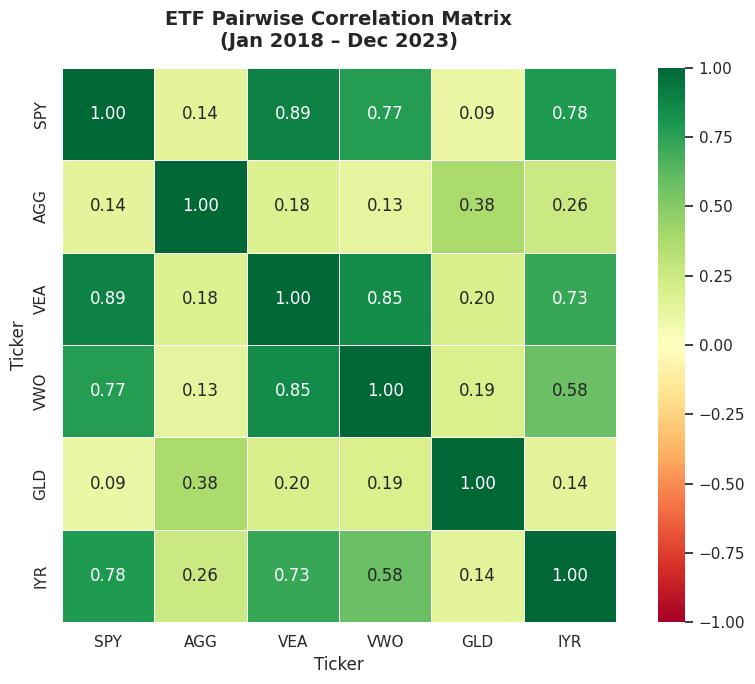


📊 Correlation Analysis
------------------------------------------
🔴 MOST correlated pair (least diversification benefit):
   VEA ↔ SPY: 0.8852

🟢 LEAST correlated pair (most diversification benefit):
   GLD ↔ SPY: 0.0944

Full Pair Rankings:
Asset 1 Asset 2  Correlation
    GLD     SPY     0.094376
    VWO     AGG     0.131346
    AGG     SPY     0.138629
    IYR     GLD     0.144384
    VEA     AGG     0.177261
    GLD     VWO     0.191885
    GLD     VEA     0.198897
    IYR     AGG     0.256967
    GLD     AGG     0.382155
    IYR     VWO     0.584094
    IYR     VEA     0.725690
    VWO     SPY     0.766981
    IYR     SPY     0.781736
    VWO     VEA     0.847047
    VEA     SPY     0.885195


In [ ]:
corr_matrix = daily_returns.corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)   # upper triangle only
sns.heatmap(
    corr_matrix,
    annot=True, fmt=".2f",
    cmap='RdYlGn',
    center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white',
    square=True, ax=ax
)
ax.set_title('ETF Pairwise Correlation Matrix\n(Jan 2018 – Dec 2023)',
             fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('corr_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Most / Least Correlated Pairs ─────────────────────────────────────────────
def get_corr_pairs(corr_matrix):
    # Mask the upper triangle to get unique pairs (excluding diagonal)
    stacked_pairs = corr_matrix.where(np.tril(np.ones(corr_matrix.shape), k=-1).astype(bool)).stack()
    # Rename the index levels to avoid 'cannot insert Ticker, already exists' error
    stacked_pairs.index.names = ['Asset 1', 'Asset 2']
    # Reset the index, which will now use the new level names as column names
    pairs = stacked_pairs.reset_index()
    # Rename the columns for clarity
    pairs.columns = ['Asset 1', 'Asset 2', 'Correlation']
    pairs = pairs.sort_values('Correlation')
    return pairs

pairs = get_corr_pairs(corr_matrix)

print("\n📊 Correlation Analysis")
print("-" * 42)
print("🔴 MOST correlated pair (least diversification benefit):")
top = pairs.iloc[-1]
print(f"   {top['Asset 1']} ↔ {top['Asset 2']}: {top['Correlation']:.4f}")

print("\n🟢 LEAST correlated pair (most diversification benefit):")
bot = pairs.iloc[0]
print(f"   {bot['Asset 1']} ↔ {bot['Asset 2']}: {bot['Correlation']:.4f}")

print("\nFull Pair Rankings:")
print(pairs.to_string(index=False))

## Part B: Efficient Frontier & Minimum Variance Portfolio (MVP)

### Modern Portfolio Theory (MPT)
Introduced by Harry Markowitz (1952), MPT states that a rational investor should not simply choose assets with the highest individual returns, but should consider the **entire portfolio's risk-return tradeoff**.

**Core Insight:** By combining assets with imperfect correlations, we can reduce portfolio risk (volatility) without proportionally reducing returns — this is **diversification**.

### The Efficient Frontier
The **Efficient Frontier** is the set of portfolios that offer the **maximum expected return for a given level of risk** (or equivalently, minimum risk for a given return). Any portfolio below the frontier is sub-optimal.

**Portfolio Mathematics:**
- **Expected Return:** $E(R_p) = \sum_i w_i \cdot \bar{r}_i$
- **Portfolio Variance:** $\sigma_p^2 = \mathbf{w}^T \Sigma \mathbf{w}$ (where $\Sigma$ = covariance matrix)
- **Sharpe Ratio:** $S = \frac{E(R_p) - r_f}{\sigma_p}$

### Key Portfolios Identified
| Portfolio | Definition |
|-----------|-----------|
| **Minimum Variance Portfolio (MVP)** | Lowest possible risk regardless of return |
| **Tangency Portfolio** | Highest Sharpe Ratio — the "best" risk-adjusted portfolio |

We use a **Monte Carlo simulation** with 10,000 random weight combinations to approximate the frontier.


In [ ]:
np.random.seed(42)

mean_returns = daily_returns.mean()
cov_matrix   = daily_returns.cov()
n_assets     = len(TICKERS)

# ── Storage arrays ─────────────────────────────────────────────────────────────
port_returns  = np.zeros(N_PORTFOLIOS)
port_vols     = np.zeros(N_PORTFOLIOS)
port_sharpes  = np.zeros(N_PORTFOLIOS)
port_weights  = np.zeros((N_PORTFOLIOS, n_assets))

print(f"🎲 Running Monte Carlo simulation ({N_PORTFOLIOS:,} portfolios)...")

for i in range(N_PORTFOLIOS):
    # Random weights that sum to 1
    w = np.random.dirichlet(np.ones(n_assets))
    port_weights[i] = w

    ann_ret = np.dot(w, mean_returns) * TRADING_DAYS
    ann_vol_p = np.sqrt(w @ (cov_matrix * TRADING_DAYS) @ w)

    port_returns[i]  = ann_ret
    port_vols[i]     = ann_vol_p
    port_sharpes[i]  = (ann_ret - RISK_FREE) / ann_vol_p

print("✅ Simulation complete.\n")

# ── Identify Key Portfolios ────────────────────────────────────────────────────
mvp_idx = np.argmin(port_vols)
tan_idx = np.argmax(port_sharpes)

mvp_weights = port_weights[mvp_idx]
tan_weights = port_weights[tan_idx]

def print_portfolio(label, weights, ret, vol, sharpe):
    print(f"\n{'='*52}")
    print(f"  {label}")
    print(f"{'='*52}")
    print(f"  Expected Annualized Return : {ret:.2%}")
    print(f"  Annualized Volatility      : {vol:.2%}")
    print(f"  Sharpe Ratio               : {sharpe:.4f}")
    print(f"\n  Asset Weights:")
    for ticker, w in zip(TICKERS, weights):
        bar = '█' * int(w * 30)
        print(f"    {ticker:>4s}  {w:6.2%}  {bar}")

print_portfolio(
    "⚖️  Minimum Variance Portfolio (MVP)",
    mvp_weights, port_returns[mvp_idx],
    port_vols[mvp_idx], port_sharpes[mvp_idx]
)
print_portfolio(
    "🎯  Tangency Portfolio (Max Sharpe)",
    tan_weights, port_returns[tan_idx],
    port_vols[tan_idx], port_sharpes[tan_idx]
)

🎲 Running Monte Carlo simulation (10,000 portfolios)...
✅ Simulation complete.


  ⚖️  Minimum Variance Portfolio (MVP)
  Expected Annualized Return : 2.06%
  Annualized Volatility      : 6.09%
  Sharpe Ratio               : 0.0101

  Asset Weights:
     SPY   4.19%  █
     AGG  85.50%  █████████████████████████
     VEA   0.14%  
     VWO   5.73%  █
     GLD   4.18%  █
     IYR   0.26%  

  🎯  Tangency Portfolio (Max Sharpe)
  Expected Annualized Return : 10.43%
  Annualized Volatility      : 13.27%
  Sharpe Ratio               : 0.6354

  Asset Weights:
     SPY  50.15%  ███████████████
     AGG   2.21%  
     VEA   0.49%  
     VWO   2.00%  
     GLD  42.21%  ████████████
     IYR   2.94%  


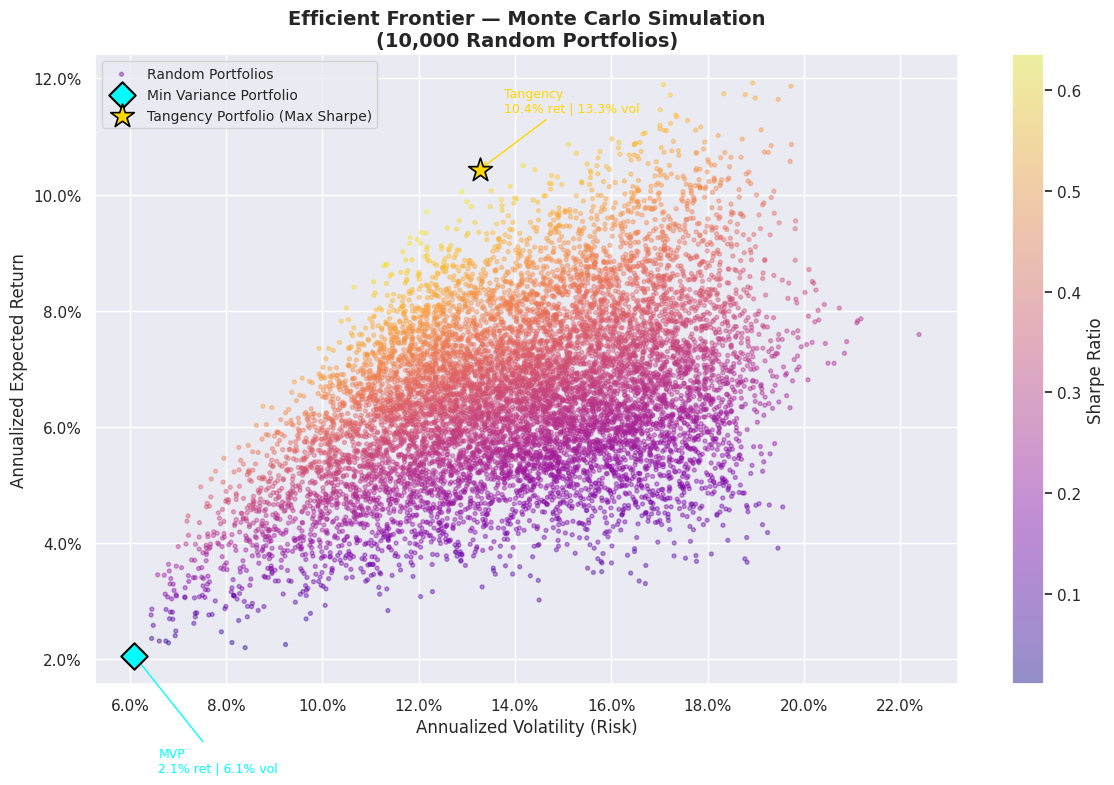

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))

sc = ax.scatter(
    port_vols, port_returns,
    c=port_sharpes, cmap='plasma',
    alpha=0.4, s=8, label='Random Portfolios'
)
plt.colorbar(sc, ax=ax, label='Sharpe Ratio')

# Mark MVP
ax.scatter(port_vols[mvp_idx], port_returns[mvp_idx],
           marker='D', color='cyan', s=180, zorder=5,
           edgecolors='black', linewidths=1.5, label='Min Variance Portfolio')
ax.annotate(f"MVP\n{port_returns[mvp_idx]:.1%} ret | {port_vols[mvp_idx]:.1%} vol",
            xy=(port_vols[mvp_idx], port_returns[mvp_idx]),
            xytext=(port_vols[mvp_idx]+0.005, port_returns[mvp_idx]-0.02),
            fontsize=9, color='cyan',
            arrowprops=dict(arrowstyle='->', color='cyan'))

# Mark Tangency
ax.scatter(port_vols[tan_idx], port_returns[tan_idx],
           marker='*', color='gold', s=320, zorder=5,
           edgecolors='black', linewidths=1.2, label='Tangency Portfolio (Max Sharpe)')
ax.annotate(f"Tangency\n{port_returns[tan_idx]:.1%} ret | {port_vols[tan_idx]:.1%} vol",
            xy=(port_vols[tan_idx], port_returns[tan_idx]),
            xytext=(port_vols[tan_idx]+0.005, port_returns[tan_idx]+0.01),
            fontsize=9, color='gold',
            arrowprops=dict(arrowstyle='->', color='gold'))

ax.set_xlabel('Annualized Volatility (Risk)', fontsize=12)
ax.set_ylabel('Annualized Expected Return', fontsize=12)
ax.set_title('Efficient Frontier — Monte Carlo Simulation\n(10,000 Random Portfolios)',
             fontsize=14, fontweight='bold')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.savefig('efficient_frontier.png', dpi=150, bbox_inches='tight')
plt.show()

## Part C: Backtesting & Rebalancing

### Methodology
**Backtesting** simulates how a portfolio strategy would have performed on historical data. Key assumptions:

- **Period:** January 1, 2021 – December 31, 2023 (out-of-sample relative to full dataset)
- **Rebalancing:** Quarterly (every ~63 trading days). Weights drift over time due to price changes; rebalancing restores target weights, enforcing discipline.
- **No transaction costs** assumed for simplicity.

### Strategies Compared
| Strategy | Weights |
|----------|---------|
| **Tangency Portfolio** | Optimized weights from Part B |
| **60/40 Benchmark** | 60% SPY / 40% AGG (classic moderate-risk benchmark) |

### Metrics
| Metric | Formula |
|--------|---------|
| **CAGR** | $(V_{end}/V_{start})^{1/T} - 1$ |
| **Max Drawdown** | $\min\left(\frac{V_t - \max_{s \le t} V_s}{\max_{s \le t} V_s}\right)$ |
| **Sharpe Ratio** | $(R_p - r_f) / \sigma_p$ |
| **Tracking Error** | $\sigma(R_{tangency} - R_{benchmark})$ |

In [ ]:
# ── Backtest Period ────────────────────────────────────────────────────────────
bt_prices = prices.loc['2021-01-01':'2023-12-31']
bt_returns = bt_prices.pct_change().dropna()
print(f"Backtest period: {bt_prices.index[0].date()} → {bt_prices.index[-1].date()}")
print(f"Trading days: {len(bt_returns)}\n")

REBAL_FREQ = 63   # ~quarterly

def backtest(daily_ret_df, weights_arr, rebal_freq=REBAL_FREQ, label="Portfolio"):
    """
    Simulate portfolio performance with periodic rebalancing.
    Returns a pd.Series of cumulative portfolio value (starts at 1.0).
    """
    weights   = np.array(weights_arr, dtype=float)
    weights  /= weights.sum()
    port_vals = [1.0]

    # Track current holdings as dollar value in each asset
    holdings = weights.copy()    # fractional allocation

    for day_idx in range(len(daily_ret_df)):
        row = daily_ret_df.iloc[day_idx].values
        # Grow holdings by today's returns
        holdings = holdings * (1 + row)
        total = holdings.sum()
        port_vals.append(total)
        # Rebalance at frequency
        if (day_idx + 1) % rebal_freq == 0:
            holdings = weights * total   # reset to target weights

    series = pd.Series(port_vals, index=[bt_returns.index[0] - pd.Timedelta(days=1)]
                                        + list(bt_returns.index),
                       name=label)
    return series

def compute_metrics(cum_series, label, rf=RISK_FREE, td=TRADING_DAYS):
    daily = cum_series.pct_change().dropna()
    total_years = len(daily) / td
    cagr = (cum_series.iloc[-1] / cum_series.iloc[0]) ** (1 / total_years) - 1
    rolling_max = cum_series.cummax()
    drawdown = (cum_series - rolling_max) / rolling_max
    max_dd = drawdown.min()
    sharpe = (daily.mean() * td - rf) / (daily.std() * np.sqrt(td))
    print(f"\n{'─'*45}")
    print(f"  📊 {label}")
    print(f"{'─'*45}")
    print(f"  CAGR              : {cagr:>8.2%}")
    print(f"  Max Drawdown      : {max_dd:>8.2%}")
    print(f"  Sharpe Ratio      : {sharpe:>8.4f}")
    print(f"  Final Portfolio   : ${cum_series.iloc[-1]:>8.4f}  (per $1 invested)")
    return {'CAGR': cagr, 'Max Drawdown': max_dd, 'Sharpe': sharpe, 'series': cum_series}

# ── Run Backtests ──────────────────────────────────────────────────────────────
tan_port = backtest(bt_returns, tan_weights, label="Tangency Portfolio")
bench_weights_raw = {'SPY': 0.60, 'AGG': 0.40}
bench_w = np.array([bench_weights_raw.get(t, 0.0) for t in TICKERS])
bench_port = backtest(bt_returns, bench_w, label="60/40 Benchmark")

print("=" * 45)
print("  BACKTEST RESULTS (2021–2023)")
print("=" * 45)
tan_metrics   = compute_metrics(tan_port,   "Tangency Portfolio")
bench_metrics = compute_metrics(bench_port, "60/40 Benchmark (SPY/AGG)")

# ── Tracking Error ─────────────────────────────────────────────────────────────
tan_daily_ret   = tan_port.pct_change().dropna()
bench_daily_ret = bench_port.pct_change().dropna()
common_idx      = tan_daily_ret.index.intersection(bench_daily_ret.index)
tracking_error  = (tan_daily_ret[common_idx] - bench_daily_ret[common_idx]).std() * np.sqrt(TRADING_DAYS)

print(f"\n{'─'*45}")
print(f"  📐 Tracking Error (Tangency vs 60/40)")
print(f"{'─'*45}")
print(f"  Annualized Tracking Error: {tracking_error:.4%}")

Backtest period: 2021-01-04 → 2023-12-29
Trading days: 752

  BACKTEST RESULTS (2021–2023)

─────────────────────────────────────────────
  📊 Tangency Portfolio
─────────────────────────────────────────────
  CAGR              :    6.31%
  Max Drawdown      :  -18.83%
  Sharpe Ratio      :   0.4019
  Final Portfolio   : $  1.2005  (per $1 invested)

─────────────────────────────────────────────
  📊 60/40 Benchmark (SPY/AGG)
─────────────────────────────────────────────
  CAGR              :    5.03%
  Max Drawdown      :  -20.76%
  Sharpe Ratio      :   0.3109
  Final Portfolio   : $  1.1577  (per $1 invested)

─────────────────────────────────────────────
  📐 Tracking Error (Tangency vs 60/40)
─────────────────────────────────────────────
  Annualized Tracking Error: 5.5679%


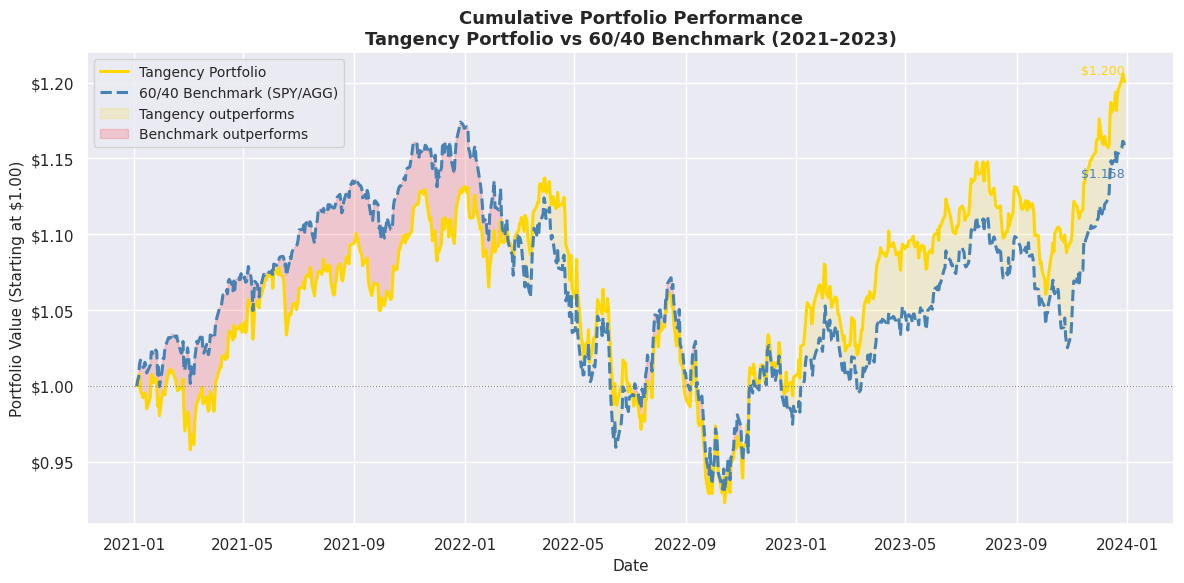

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(tan_port.index,   tan_port.values,
        label='Tangency Portfolio', color='gold', linewidth=2.2)
ax.plot(bench_port.index, bench_port.values,
        label='60/40 Benchmark (SPY/AGG)', color='steelblue',
        linewidth=2.2, linestyle='--')

ax.fill_between(tan_port.index, tan_port.values, bench_port.values,
                where=(tan_port.values >= bench_port.values),
                alpha=0.15, color='gold', label='Tangency outperforms')
ax.fill_between(tan_port.index, tan_port.values, bench_port.values,
                where=(tan_port.values <  bench_port.values),
                alpha=0.15, color='red', label='Benchmark outperforms')

ax.set_title('Cumulative Portfolio Performance\nTangency Portfolio vs 60/40 Benchmark (2021–2023)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Portfolio Value (Starting at $1.00)', fontsize=11)
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:.2f}'))
ax.legend(fontsize=10)
ax.axhline(1.0, color='gray', linewidth=0.8, linestyle=':')

# Annotate final values
for series, color, offset in [(tan_port, 'gold', 0.005),
                               (bench_port, 'steelblue', -0.02)]:
    ax.annotate(f"${series.iloc[-1]:.3f}",
                xy=(series.index[-1], series.iloc[-1]),
                xytext=(series.index[-1], series.iloc[-1] + offset),
                fontsize=9, color=color, ha='right')

plt.tight_layout()
plt.savefig('backtest_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Part D: Tax-Aware Asset Location

### Strategy Overview
A portfolio of $500,000 is split across two account types:

| Account | Balance | Tax Treatment |
|---------|---------|--------------|
| **Taxable Account** | $300,000 | Gains taxed at **15% capital gains rate** |
| **Tax-Deferred (IRA)** | $200,000 | Withdrawals taxed as **ordinary income (24%)** |

### Tax Location Principles
The goal of **asset location** is to maximize after-tax returns by placing each asset in the account type that shields it most efficiently:

1. **Tax-Deferred (IRA) → Income-generating assets (bonds, REITs)**
   - AGG (bonds) and IYR (REITs) distribute frequent ordinary income dividends
   - Inside an IRA, these distributions compound tax-free until withdrawal
   - Paying 24% ordinary income only at withdrawal is better than paying it annually in a taxable account

2. **Taxable Account → Growth/equity assets**
   - SPY, VEA, VWO, GLD grow primarily via capital appreciation
   - Qualified dividends and long-term gains taxed at a lower 15% rate
   - More tax-efficient to hold in taxable; unrealized gains are not taxed until sale

### After-Tax Return Estimation
- **Taxable assets:** After-tax return = Gross return × (1 − 0.15)
- **Tax-deferred assets:** After-tax return = Gross return × (1 − 0.24)
- **Blended after-tax return:** Weighted average across both accounts

In [ ]:
TAXABLE_ACCT   = 300_000
IRA_ACCT       = 200_000
CGT_RATE       = 0.15    # capital gains tax (taxable)
ORD_INCOME_RATE= 0.24    # ordinary income tax (IRA withdrawal)

# ── Dollar Allocations from Tangency Weights ───────────────────────────────────
dollar_alloc = {ticker: w * TOTAL_CAPITAL
                for ticker, w in zip(TICKERS, tan_weights)}

print("=" * 60)
print("  💼 Tangency Portfolio — Dollar Allocations ($500,000)")
print("=" * 60)
for t, d in dollar_alloc.items():
    print(f"  {t:>4s}  {d:>10,.2f}  ({d/TOTAL_CAPITAL:>6.2%})")
print(f"  {'TOTAL':>4s}  {sum(dollar_alloc.values()):>10,.2f}")

# ── Asset Location Logic ───────────────────────────────────────────────────────
# Priority for IRA: income-heavy assets (AGG, IYR)
# Priority for Taxable: growth/equity assets (SPY, VEA, VWO, GLD)

IRA_PRIORITY     = ['AGG', 'IYR']      # income-generating → shelter from ordinary income tax
TAXABLE_PRIORITY = ['SPY', 'VEA', 'VWO', 'GLD']  # growth → cap gains rate

ira_alloc     = {}
taxable_alloc = {}
ira_remaining     = IRA_ACCT
taxable_remaining = TAXABLE_ACCT

# Fill IRA with income assets first
for ticker in IRA_PRIORITY:
    amount = dollar_alloc.get(ticker, 0)
    placed = min(amount, ira_remaining)
    ira_alloc[ticker] = placed
    ira_remaining -= placed
    overflow = amount - placed
    if overflow > 0:
        taxable_alloc[ticker] = overflow
        taxable_remaining -= overflow

# Fill Taxable with growth assets
for ticker in TAXABLE_PRIORITY:
    amount = dollar_alloc.get(ticker, 0)
    placed = min(amount, taxable_remaining)
    taxable_alloc[ticker] = placed
    taxable_remaining -= placed
    overflow = amount - placed
    if overflow > 0:
        ira_alloc[ticker] = ira_alloc.get(ticker, 0) + min(overflow, ira_remaining)
        ira_remaining -= min(overflow, ira_remaining)

print("\n" + "=" * 60)
print("  🏦 TAX-DEFERRED (IRA) — $200,000")
print("=" * 60)
ira_total = 0
for t in TICKERS:
    amt = ira_alloc.get(t, 0)
    ira_total += amt
    if amt > 0:
        print(f"  {t:>4s}  ${amt:>10,.2f}  ← income-generating; shielded from annual taxation")
print(f"  {'TOTAL':>4s}  ${ira_total:>10,.2f}")

print("\n" + "=" * 60)
print("  📈 TAXABLE ACCOUNT — $300,000")
print("=" * 60)
tax_total = 0
for t in TICKERS:
    amt = taxable_alloc.get(t, 0)
    tax_total += amt
    if amt > 0:
        tag = "← growth asset; benefits from 15% cap gains rate"
        print(f"  {t:>4s}  ${amt:>10,.2f}  {tag}")
print(f"  {'TOTAL':>4s}  ${tax_total:>10,.2f}")

# ── After-Tax Return Estimation ────────────────────────────────────────────────
print("\n" + "=" * 60)
print("  📊 ESTIMATED AFTER-TAX RETURN CALCULATION")
print("=" * 60)

# Use backtested CAGR as "gross return" proxy
gross_ret = tan_metrics['CAGR']

# Weight by account proportion
taxable_weight = TAXABLE_ACCT / TOTAL_CAPITAL       # 0.60
ira_weight     = IRA_ACCT     / TOTAL_CAPITAL       # 0.40

after_tax_taxable = gross_ret * (1 - CGT_RATE)
after_tax_ira     = gross_ret * (1 - ORD_INCOME_RATE)
blended_after_tax = (taxable_weight * after_tax_taxable
                   + ira_weight     * after_tax_ira)

print(f"\n  Gross Portfolio Return (CAGR from backtest): {gross_ret:>8.4%}")
print(f"\n  Taxable Account ({taxable_weight:.0%} of portfolio):")
print(f"    Gross Return                            : {gross_ret:.4%}")
print(f"    Capital Gains Tax Rate                  : {CGT_RATE:.0%}")
print(f"    After-Tax Return                        : {after_tax_taxable:.4%}")
print(f"\n  Tax-Deferred / IRA ({ira_weight:.0%} of portfolio):")
print(f"    Gross Return                            : {gross_ret:.4%}")
print(f"    Ordinary Income Tax Rate (on withdrawal): {ORD_INCOME_RATE:.0%}")
print(f"    After-Tax Return                        : {after_tax_ira:.4%}")
print(f"\n{'═'*60}")
print(f"  🎯 BLENDED AFTER-TAX PORTFOLIO RETURN     : {blended_after_tax:.4%}")
print(f"  💰 Estimated After-Tax Annual Gain        : ${TOTAL_CAPITAL * blended_after_tax:>10,.2f}")
print(f"{'═'*60}")
print("\n  ℹ️  Note: This is a simplified estimate. Actual after-tax")
print("  returns depend on holding periods, dividend yields,")
print("  tax-loss harvesting, and state/local taxes.")

  💼 Tangency Portfolio — Dollar Allocations ($500,000)
   SPY  250,744.43  (50.15%)
   AGG   11,037.25  ( 2.21%)
   VEA    2,443.92  ( 0.49%)
   VWO    9,999.46  ( 2.00%)
   GLD  211,053.71  (42.21%)
   IYR   14,721.23  ( 2.94%)
  TOTAL  500,000.00

  🏦 TAX-DEFERRED (IRA) — $200,000
   AGG  $ 11,037.25  ← income-generating; shielded from annual taxation
   GLD  $174,241.52  ← income-generating; shielded from annual taxation
   IYR  $ 14,721.23  ← income-generating; shielded from annual taxation
  TOTAL  $200,000.00

  📈 TAXABLE ACCOUNT — $300,000
   SPY  $250,744.43  ← growth asset; benefits from 15% cap gains rate
   VEA  $  2,443.92  ← growth asset; benefits from 15% cap gains rate
   VWO  $  9,999.46  ← growth asset; benefits from 15% cap gains rate
   GLD  $ 36,812.19  ← growth asset; benefits from 15% cap gains rate
  TOTAL  $300,000.00

  📊 ESTIMATED AFTER-TAX RETURN CALCULATION

  Gross Portfolio Return (CAGR from backtest):  6.3145%

  Taxable Account (60% of portfolio):
    Gr

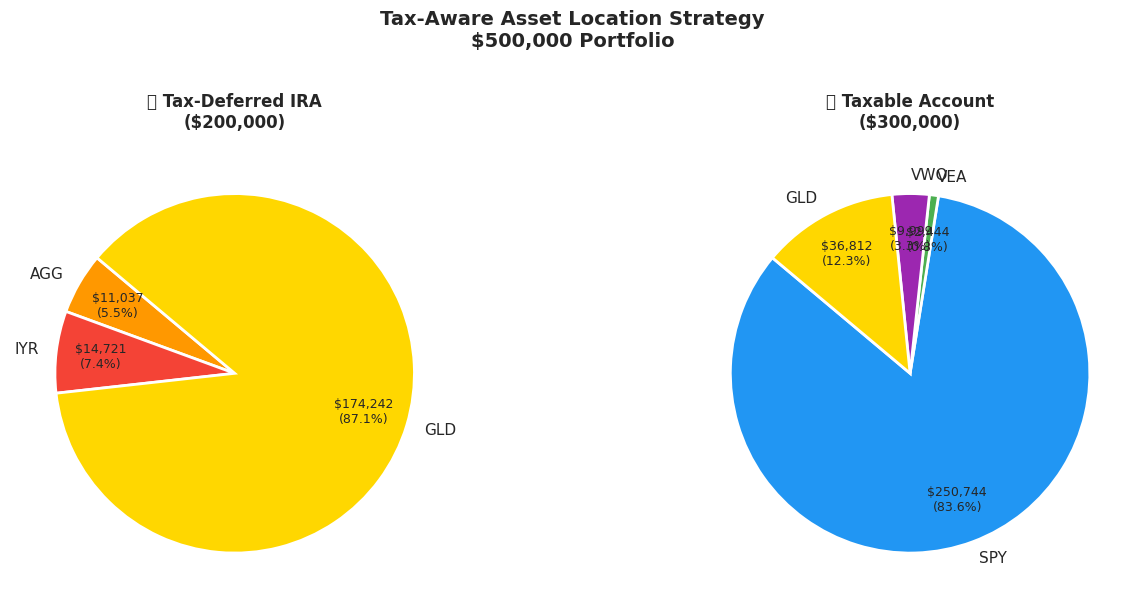


📋 Tax Location Summary Table
    Total Allocation   IRA ($) Taxable ($)     Primary Account
ETF                                                           
SPY         $250,744        $0    $250,744             Taxable
AGG          $11,037   $11,037          $0  IRA (Tax-Deferred)
VEA           $2,444        $0      $2,444             Taxable
VWO           $9,999        $0      $9,999             Taxable
GLD         $211,054  $174,242     $36,812  IRA (Tax-Deferred)
IYR          $14,721   $14,721          $0  IRA (Tax-Deferred)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

def make_pie(ax, alloc_dict, title, color_map):
    labels = [t for t, v in alloc_dict.items() if v > 0]
    values = [v for v in alloc_dict.values() if v > 0]
    colors = [color_map.get(t, '#999') for t in labels]
    wedges, texts, autotexts = ax.pie(
        values, labels=labels, colors=colors,
        autopct=lambda p: f'${p/100*sum(values):,.0f}\n({p:.1f}%)',
        startangle=140, pctdistance=0.75,
        wedgeprops=dict(edgecolor='white', linewidth=2)
    )
    for at in autotexts:
        at.set_fontsize(9)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=15)

COLORS = {
    'SPY': '#2196F3', 'AGG': '#FF9800', 'VEA': '#4CAF50',
    'VWO': '#9C27B0', 'GLD': '#FFD700', 'IYR': '#F44336'
}

make_pie(axes[0], ira_alloc,     f"🏦 Tax-Deferred IRA\n(${IRA_ACCT:,})", COLORS)
make_pie(axes[1], taxable_alloc, f"📈 Taxable Account\n(${TAXABLE_ACCT:,})", COLORS)

fig.suptitle('Tax-Aware Asset Location Strategy\n$500,000 Portfolio',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('tax_location.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Summary Table ──────────────────────────────────────────────────────────────
summary_rows = []
for t in TICKERS:
    ira_amt = ira_alloc.get(t, 0)
    tax_amt = taxable_alloc.get(t, 0)
    acct    = 'IRA (Tax-Deferred)' if ira_amt >= tax_amt else 'Taxable'
    summary_rows.append({
        'ETF': t,
        'Total Allocation': f"${dollar_alloc.get(t,0):,.0f}",
        'IRA ($)': f"${ira_amt:,.0f}",
        'Taxable ($)': f"${tax_amt:,.0f}",
        'Primary Account': acct
    })

summary_df = pd.DataFrame(summary_rows).set_index('ETF')
print("\n📋 Tax Location Summary Table")
print(summary_df.to_string())